# Занятие 01. Первичный анализ внешнего набора данных: Zenodo PMSM inverter fault diagnosis

## Теоретический блок

Набор данных рассматривается как инженерная таблица наблюдений. Наблюдение -
одна строка, соответствующая измеренному или расчетному состоянию объекта.
Признак (feature) - входная величина анализа. Диагностический столбец -
величина, полезная для объяснения источника данных, но потенциально опасная
как вход модели из-за утечки данных (data leakage).

Источник: https://zenodo.org/records/14482932.

## Описание источника

Набор содержит измерения инвертора постоянно-магнитной синхронной машины (Permanent Magnet Synchronous Motor, PMSM) в нормальном режиме и при отказах. Он полезен для связи анализа данных с диагностикой силовой электроники.

Структура данных: Feature-CSV содержит режимные признаки: прокси-момент, напряжение звена постоянного тока, ток и среднюю температуру. Diagnostics-CSV хранит максимальную температуру полумоста, код отказа FDD, фазные токи, мощности и дополнительные диагностические разности.

Особенность обработки: Код отказа и диагностические разности нельзя автоматически включать в базовую модель, поскольку они раскрывают исходную разметку или являются производными диагностическими величинами.

## План анализа

1. Проверить, какие файлы фактически загружены и какая версия данных
   используется в блокноте.
2. Составить паспорт набора данных и таблицу ролей столбцов.
3. Выполнить аудит качества данных: пропуски, диапазоны, распределения,
   группировка по профилям или датам.
4. Построить несколько визуализаций, объясняющих структуру признаков и
   возможные риски утечки данных.
5. Сформулировать вывод о пригодности источника для регрессии и
   классификации.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "data").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Не найден корень проекта appai_lab.")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_diagnostics.csv"
METADATA_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_metadata.md"
FALLBACK_FEATURES_FILE = DATA_DIR / "practice_02_motor_efficiency_features.csv"
FALLBACK_DIAGNOSTICS_FILE = DATA_DIR / "practice_02_motor_efficiency_diagnostics.csv"

RANDOM_STATE = 20260507
GROUP_COLUMN = "profile_id"
TIME_COLUMN = "time_index"
TIME_KIND = "время измерения из исходного файла в условных секундах эксперимента"
DATASET_ID = "zenodo_pmsm_inverter_fault"
DATASET_TITLE = "Zenodo PMSM inverter fault diagnosis"
ALLOW_BASE_FALLBACK = False

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


def load_external_or_fallback():
    if FEATURES_FILE.exists() and DIAGNOSTICS_FILE.exists():
        features = pd.read_csv(FEATURES_FILE)
        diagnostics = pd.read_csv(DIAGNOSTICS_FILE)
        source_status = "external"
    else:
        if not ALLOW_BASE_FALLBACK:
            raise FileNotFoundError(
                "Не найдены подготовленные внешние CSV. Выполните "
                "`venv/bin/python scripts/prepare_external_datasets.py`. "
                "Для аварийной демонстрации можно вручную установить "
                "ALLOW_BASE_FALLBACK = True, но тогда выводы блокнота будут "
                "относиться к базовому синтетическому набору, а не к внешнему источнику."
            )
        print(
            "Предупреждение: используется базовый синтетический CSV. "
            "Содержательные выводы по внешнему источнику в этом режиме недействительны."
        )
        features = pd.read_csv(FALLBACK_FEATURES_FILE)
        diagnostics = pd.read_csv(FALLBACK_DIAGNOSTICS_FILE)
        source_status = "fallback_base"
    full = features.merge(diagnostics, on="sample_id", how="left", validate="one_to_one")
    return features, diagnostics, full, source_status


def plot_correlation_heatmap(data, columns, title):
    corr = data[columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(max(7, 0.75 * len(columns)), max(5, 0.65 * len(columns))))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Коэффициент корреляции")
    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


def group_holdout_split(data, group_column, test_share=0.25, target_column=None):
    groups = np.array(sorted(data[group_column].dropna().unique()))
    test_count = max(1, int(np.ceil(len(groups) * test_share)))
    test_groups = groups[-test_count:]
    test_mask = data[group_column].isin(test_groups)
    train_idx = data.index[~test_mask]
    test_idx = data.index[test_mask]

    if target_column is None or target_column not in data.columns or data[target_column].nunique() < 2:
        return train_idx, test_idx, test_groups

    def _has_two_classes(index):
        return data.loc[index, target_column].nunique() >= 2

    if _has_two_classes(train_idx) and _has_two_classes(test_idx):
        return train_idx, test_idx, test_groups

    selected_groups = []
    for class_value in sorted(data[target_column].dropna().unique()):
        class_groups = np.array(sorted(data.loc[data[target_column] == class_value, group_column].dropna().unique()))
        class_test_count = max(1, int(np.ceil(len(class_groups) * test_share)))
        selected_groups.extend(class_groups[-class_test_count:].tolist())
    test_groups = np.array(sorted(set(selected_groups)))
    test_mask = data[group_column].isin(test_groups)
    train_idx = data.index[~test_mask]
    test_idx = data.index[test_mask]
    if not (_has_two_classes(train_idx) and _has_two_classes(test_idx)):
        raise ValueError(
            "Групповое разбиение не содержит оба класса в обучающей и тестовой "
            "выборках. Проверьте profile_id или правило формирования is_allowed."
        )
    return train_idx, test_idx, test_groups


def validate_features(features, forbidden, context):
    leaked = set(features) & set(forbidden)
    if leaked:
        raise AssertionError(
            f"Обнаружена утечка данных в {context}: {sorted(leaked)}"
        )
    return list(features)


def existing_columns(data, columns):
    result = []
    for column in columns:
        if column in data.columns and column not in result:
            result.append(column)
    return result


def compact_numeric_profile(data, columns):
    selected = data[existing_columns(data, columns)].select_dtypes(include=[np.number])
    rows = []
    for column in selected.columns:
        series = selected[column]
        rows.append(
            dict(
                column=column,
                missing_count=int(series.isna().sum()),
                missing_share=float(series.isna().mean()),
                unique_count=int(series.nunique(dropna=True)),
                minimum=float(series.min()),
                q25=float(series.quantile(0.25)),
                median=float(series.median()),
                q75=float(series.quantile(0.75)),
                maximum=float(series.max()),
                mean=float(series.mean()),
                std=float(series.std()),
            )
        )
    return pd.DataFrame(rows).set_index("column")


def print_missing_interpretation(data):
    missing_share = data.isna().mean().sort_values(ascending=False)
    nonzero = missing_share[missing_share > 0]
    if nonzero.empty:
        print("Интерпретация: пропуски не обнаружены. Для учебной работы это означает, что можно сосредоточиться на диапазонах, группах и риске утечки данных.")
    else:
        print("Интерпретация: обнаружены пропуски. Перед моделированием необходимо выбрать способ обработки и объяснить его физический смысл.")
        print(nonzero.head(10).to_string())


def print_group_interpretation(data, group_column):
    if group_column not in data.columns:
        print("Групповой столбец отсутствует. Следует явно обосновать выбранный способ разбиения данных.")
        return
    group_counts = data[group_column].value_counts()
    print(f"Число групп: {group_counts.shape[0]}.")
    print(f"Минимальный размер группы: {group_counts.min()}.")
    print(f"Максимальный размер группы: {group_counts.max()}.")
    print(
        "Интерпретация: если наблюдения внутри одной группы близки по происхождению, "
        "то строки одной группы нельзя произвольно делить между обучением и тестом."
    )


def print_top_correlations(data, columns, target_column, top_n=5):
    candidate_columns = [column for column in columns if column != target_column] + [target_column]
    usable_columns = existing_columns(data, candidate_columns)
    if target_column not in usable_columns:
        print(f"Целевая переменная {target_column} отсутствует.")
        return pd.DataFrame()
    corr = data[usable_columns].corr(numeric_only=True)[target_column].drop(target_column, errors="ignore")
    result = corr.reindex(corr.abs().sort_values(ascending=False).index).head(top_n).to_frame("correlation")
    print(
        "Интерпретация: высокая корреляция показывает сильную линейную связь, "
        "но не доказывает причинность. Также необходимо проверить, не является ли "
        "признак производным от целевой переменной."
    )
    return result


def interpret_regression_metrics(metrics):
    best_model = metrics["R2"].idxmax()
    best_r2 = metrics.loc[best_model, "R2"]
    best_mae = metrics.loc[best_model, "MAE"]
    print(f"Лучшая модель по R2: {best_model}.")
    print(f"R2 = {best_r2:.4f}; MAE = {best_mae:.4f}.")
    print(
        "Интерпретация: MAE показывает средний модуль ошибки в единицах целевой "
        "переменной. R2 показывает долю объясненной дисперсии относительно "
        "модели среднего значения. Высокий R2 должен дополнительно проверяться "
        "на утечку данных и устойчивость к способу разбиения."
    )


def interpret_split_comparison(metrics):
    if {"group_holdout", "random_split"}.issubset(metrics.index):
        delta = metrics.loc["random_split", "R2"] - metrics.loc["group_holdout", "R2"] if "R2" in metrics.columns else np.nan
        print(f"Разница random_split - group_holdout по R2: {delta:.4f}.")
        print(
            "Интерпретация: если случайное разбиение существенно лучше группового, "
            "это может указывать на информационную близость соседних наблюдений и "
            "завышение качества при случайном перемешивании."
        )
    else:
        print("Сравнение разбиений недоступно.")


def interpret_classification_metrics(metrics):
    if "strict_decision_tree" in metrics.index:
        row = metrics.loc["strict_decision_tree"]
        print(f"Accuracy строгого дерева: {row['accuracy']:.4f}.")
        print(f"Recall недопустимого класса: {row['recall_not_allowed']:.4f}.")
        print(f"Доля ложных разрешений: {row['dangerous_false_allowed_rate']:.4f}.")
        print(
            "Интерпретация: для инженерной безопасности recall недопустимого класса "
            "и доля ложных разрешений важнее, чем одна общая accuracy."
        )


def interpret_depth_metrics(metrics):
    best_depth = metrics["f1_not_allowed"].idxmax()
    print(f"Наилучшая глубина по F1 недопустимого класса: {best_depth}.")
    print(
        "Интерпретация: рост глубины увеличивает гибкость дерева, но может привести "
        "к переобучению. Следует выбирать не максимальную глубину, а глубину, которая "
        "дает приемлемый баланс качества и интерпретируемости."
    )


def plot_missingness(data, title):
    missing_share = data.isna().mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, max(3, 0.25 * len(missing_share))))
    ax.barh(missing_share.index[::-1], missing_share.values[::-1], color="#4c78a8")
    ax.set_xlabel("Доля пропусков")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_boxplots(data, columns, title):
    selected = existing_columns(data, columns)
    if not selected:
        print("Нет доступных столбцов для построения диаграмм размаха.")
        return
    fig, axes = plt.subplots(1, len(selected), figsize=(max(10, 2.2 * len(selected)), 4))
    axes = np.atleast_1d(axes)
    for ax, column in zip(axes, selected):
        ax.boxplot(data[column].dropna(), vert=True)
        ax.set_title(column, rotation=20)
        ax.set_ylabel("Значение")
    plt.suptitle(title, y=1.04)
    plt.tight_layout()
    plt.show()


def plot_time_or_group_profile(data, value_column, title):
    if value_column not in data.columns:
        print(f"Столбец {value_column} отсутствует.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    if TIME_COLUMN in data.columns:
        sample = data.sort_values([GROUP_COLUMN, TIME_COLUMN]).head(800)
        axes[0].plot(sample[TIME_COLUMN], sample[value_column], marker=".", linestyle="none", alpha=0.55)
        axes[0].set_xlabel(f"{TIME_COLUMN}: {TIME_KIND}")
        axes[0].set_ylabel(value_column)
        axes[0].set_title("Фрагмент временного, порядкового или траекторного профиля")
    else:
        axes[0].set_axis_off()
    if GROUP_COLUMN in data.columns:
        group_summary = data.groupby(GROUP_COLUMN)[value_column].median().head(40)
        axes[1].bar(group_summary.index.astype(str), group_summary.values, color="#f58518")
        axes[1].set_xlabel(GROUP_COLUMN)
        axes[1].set_ylabel(f"Медиана {value_column}")
        axes[1].set_title("Медианное значение по группам")
        axes[1].tick_params(axis="x", rotation=45)
    else:
        axes[1].set_axis_off()
    plt.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()


def role_table(feature_columns, diagnostic_columns, regression_target, classification_target):
    rows = []
    all_columns = list(feature_columns) + [column for column in diagnostic_columns if column not in feature_columns]
    for column in all_columns:
        if column == "sample_id":
            role = "служебный идентификатор"
        elif column in {GROUP_COLUMN, TIME_COLUMN}:
            role = "служебный или группировочный столбец"
        elif column == regression_target:
            role = "целевая переменная регрессии"
        elif column == classification_target:
            role = "целевая переменная классификации"
        elif column in feature_columns:
            role = "доступный столбец feature-CSV"
        else:
            role = "диагностический столбец diagnostics-CSV"
        rows.append(dict(column=column, role=role))
    return pd.DataFrame(rows)


features_df, diagnostics_df, full_df, source_status = load_external_or_fallback()
print("Источник данных:", source_status)
print("Файл признаков:", FEATURES_FILE if source_status == "external" else FALLBACK_FEATURES_FILE)
print("Размер feature-таблицы:", features_df.shape)
features_df.head()


Источник данных: external
Файл признаков: /mnt/f/projects/appai_lab/data/processed/external/zenodo_pmsm_inverter_fault_features.csv
Размер feature-таблицы: (10892, 8)


,sample_id,profile_id,time_index,torque_proxy_nm,voltage_v,current_a,temperature_c,is_allowed
0,1,1001,0.0,5.642229,21.994135,6.118761,11.430371,1
1,2,1001,0.1,5.587977,21.994135,6.126954,11.954090,1
2,3,1001,0.2,12.912023,21.994135,6.078809,11.430230,1
3,4,1001,0.3,9.042033,21.994135,6.039383,11.843363,1
4,5,1001,0.4,5.533724,17.106549,6.022350,11.320267,1


In [2]:
metadata_text = METADATA_FILE.read_text(encoding="utf-8") if METADATA_FILE.exists() else "Метаданные не найдены."
print(metadata_text)


# Zenodo PMSM inverter fault diagnosis

- Идентификатор: `zenodo_pmsm_inverter_fault`.
- Источник: https://zenodo.org/records/14482932.
- Лицензия и доступ: CC BY 4.0.
- Статус подготовки: `prepared`.
- Число строк в компактной учебной выборке: 10892.

Методическое назначение: расширенные блокноты занятий 1-3 с реальными
или открытыми инженерными данными. Feature-CSV используется для базовой
модели, diagnostics-CSV - для пояснения происхождения целевых переменных,
ограничений и возможной утечки данных.

Дополнительные замечания:
- Целевая переменная регрессии: `max_bridge_temp_c`.
- Целевая переменная классификации: `is_allowed`, где `F0` трактуется как нормальная работа.
- `torque_proxy_nm` является расчетным прокси-показателем, полученным из `Power_AC` и фиксированной угловой скорости 10 рад/с; сама скорость не включена в feature-CSV, так как в источнике она не изменяется.
- `profile_id` сформирован как сегмент внутри кода отказа, чтобы групповое тестирование включало нормальные и от

In [3]:
dataset_passport = pd.DataFrame(
    {
        "field": [
            "dataset_id",
            "title",
            "source_status",
            "rows_features",
            "columns_features",
            "group_column",
            "time_column",
            "regression_target",
            "classification_target",
        ],
        "value": [
            DATASET_ID,
            DATASET_TITLE,
            source_status,
            features_df.shape[0],
            features_df.shape[1],
            GROUP_COLUMN,
            TIME_COLUMN,
            "max_bridge_temp_c",
            "is_allowed",
        ],
    }
)
dataset_passport


,field,value
0,dataset_id,zenodo_pmsm_inverter_fault
1,title,Zenodo PMSM inverter fault diagnosis
2,source_status,external
3,rows_features,10892
4,columns_features,8
5,group_column,profile_id
6,time_column,time_index
7,regression_target,max_bridge_temp_c
8,classification_target,is_allowed


In [4]:
print(
    "Интерпретация паспорта: этот блок фиксирует не только размер таблицы, "
    "но и единицу наблюдения, групповой столбец и целевые переменные. "
    "Без такого паспорта трудно доказать, что последующее разбиение данных "
    "и выбор признаков выполнены корректно."
)
print_group_interpretation(features_df, GROUP_COLUMN)


Интерпретация паспорта: этот блок фиксирует не только размер таблицы, но и единицу наблюдения, групповой столбец и целевые переменные. Без такого паспорта трудно доказать, что последующее разбиение данных и выбор признаков выполнены корректно.
Число групп: 48.
Минимальный размер группы: 34.
Максимальный размер группы: 250.
Интерпретация: если наблюдения внутри одной группы близки по происхождению, то строки одной группы нельзя произвольно делить между обучением и тестом.


In [5]:
column_roles = role_table(
    features_df.columns.tolist(),
    diagnostics_df.columns.tolist(),
    'max_bridge_temp_c',
    'is_allowed',
)
column_roles


,column,role
0,sample_id,служебный идентификатор
1,profile_id,служебный или группировочный столбец
2,time_index,служебный или группировочный столбец
3,torque_proxy_nm,доступный столбец feature-CSV
4,voltage_v,доступный столбец feature-CSV
5,current_a,доступный столбец feature-CSV
6,temperature_c,доступный столбец feature-CSV
7,is_allowed,целевая переменная классификации
8,max_bridge_temp_c,целевая переменная регрессии
9,fault_code,диагностический столбец diagnostics-CSV


## Как читать таблицу ролей столбцов

Таблица ролей показывает, какие поля можно использовать как признаки, а какие
нужны только для диагностики. Служебный идентификатор `sample_id` не имеет
физического смысла режима. Групповой столбец применяется для корректного
разбиения. Целевые переменные не должны попадать во вход модели, иначе
возникает утечка данных (data leakage), то есть модель получает ответ или его
производную форму.


## Аудит качества данных

Аудит качества данных включает проверку пропусков, диапазонов, числа
уникальных значений и устойчивости группировки. Для внешних источников это
особенно важно, поскольку исходные данные могли быть получены из разных
экспериментов, поездок, профилей или режимов отказа.


In [6]:
analysis_columns = ['torque_proxy_nm', 'voltage_v', 'current_a', 'temperature_c', 'max_bridge_temp_c']
compact_numeric_profile(full_df, analysis_columns)


,missing_count,missing_share,unique_count,minimum,q25,median,q75,maximum,mean,std
column,,,,,,,,,,
torque_proxy_nm,0,0.0,471,0.000000,0.542522,1.953079,5.877322,62.661290,3.671851,4.147226
voltage_v,0,0.0,17,2.443793,17.106549,21.994135,21.994135,85.532747,19.828107,5.742805
current_a,0,0.0,3563,0.034560,3.446528,5.459785,6.464282,9.781584,4.941134,2.205677
temperature_c,0,0.0,4318,10.415035,12.348347,12.593238,17.346200,20.960235,14.292217,2.819565
max_bridge_temp_c,0,0.0,209,11.401305,13.735092,14.156756,22.517270,32.673387,17.310130,5.298965


In [7]:
missing_table = (
    full_df.isna().sum().rename("missing_count").to_frame()
    .assign(missing_share=lambda x: x["missing_count"] / len(full_df))
)
missing_table[missing_table["missing_count"] > 0]


,missing_count,missing_share


In [8]:
print_missing_interpretation(full_df)


Интерпретация: пропуски не обнаружены. Для учебной работы это означает, что можно сосредоточиться на диапазонах, группах и риске утечки данных.


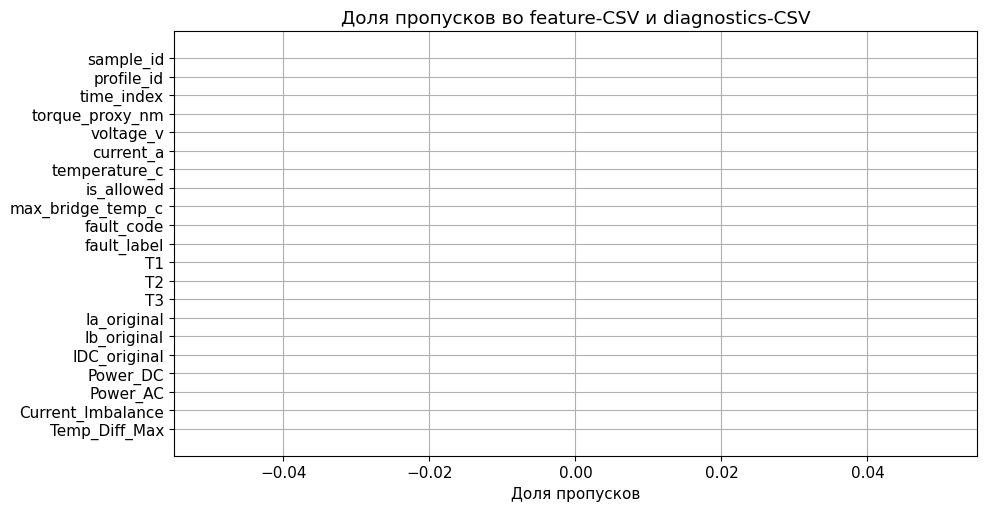

In [9]:
plot_missingness(full_df, "Доля пропусков во feature-CSV и diagnostics-CSV")


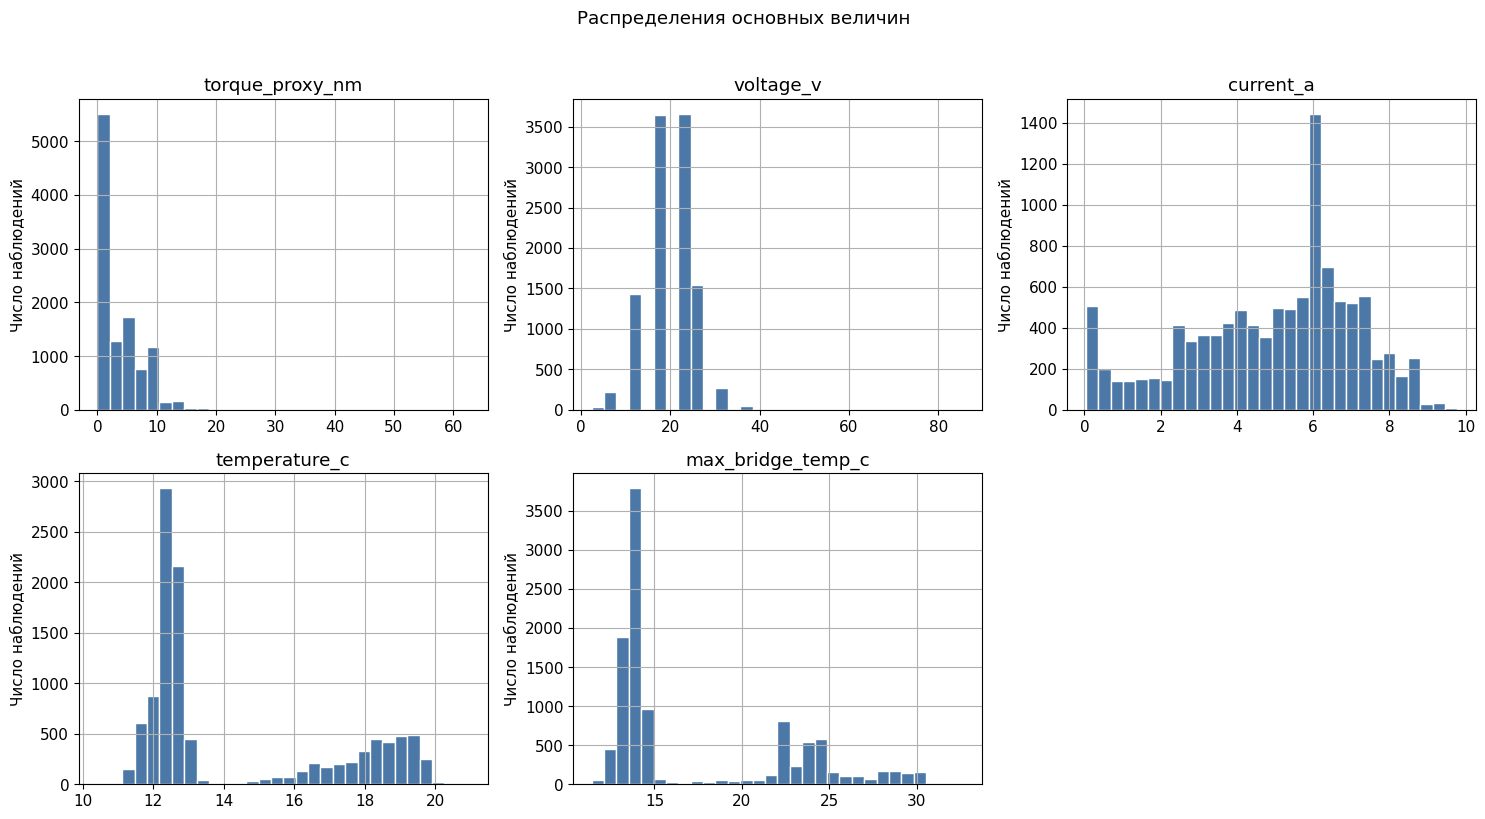

In [10]:
numeric_columns = full_df.select_dtypes(include=[np.number]).columns.tolist()
shown_columns = [column for column in analysis_columns if column in numeric_columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, column in zip(axes, shown_columns[:6]):
    ax.hist(full_df[column].dropna(), bins=30, color="#4c78a8", edgecolor="white")
    ax.set_title(column)
    ax.set_ylabel("Число наблюдений")
for ax in axes[len(shown_columns[:6]):]:
    ax.set_axis_off()
plt.suptitle("Распределения основных величин", y=1.02)
plt.tight_layout()
plt.show()


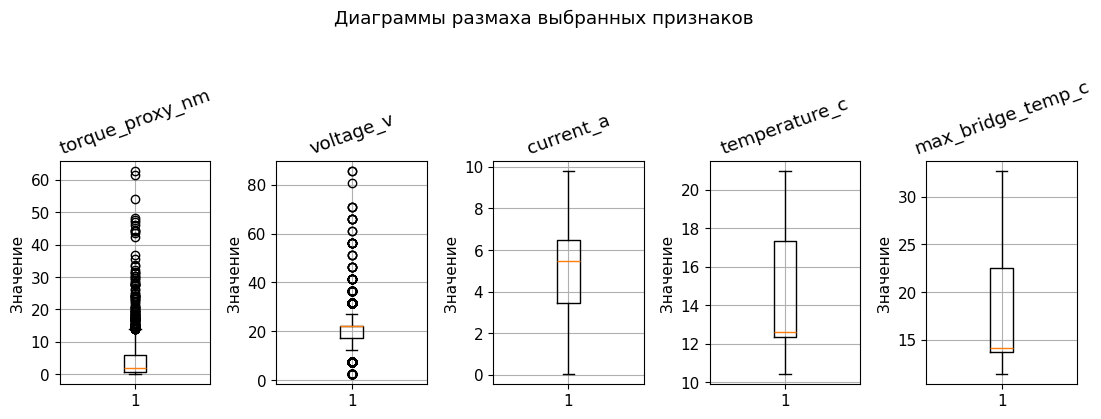

In [11]:
plot_boxplots(full_df, analysis_columns[:6], "Диаграммы размаха выбранных признаков")


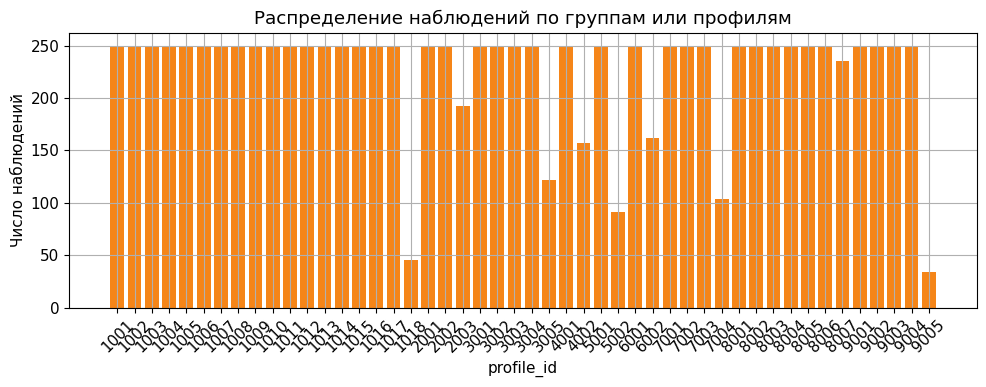

profile_id
1001    250
1002    250
1003    250
1004    250
1005    250
1006    250
1007    250
1008    250
1009    250
1010    250
1011    250
1012    250
1013    250
1014    250
1015    250
1016    250
1017    250
1018     45
2001    250
2002    250
Name: count, dtype: int64

In [12]:
if GROUP_COLUMN in features_df.columns:
    group_counts = features_df[GROUP_COLUMN].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(group_counts.index.astype(str), group_counts.values, color="#f58518")
    ax.set_xlabel(GROUP_COLUMN)
    ax.set_ylabel("Число наблюдений")
    ax.set_title("Распределение наблюдений по группам или профилям")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
plt.show()
group_counts.head(20) if GROUP_COLUMN in features_df.columns else "Групповой столбец отсутствует"


In [13]:
print_group_interpretation(features_df, GROUP_COLUMN)


Число групп: 48.
Минимальный размер группы: 34.
Максимальный размер группы: 250.
Интерпретация: если наблюдения внутри одной группы близки по происхождению, то строки одной группы нельзя произвольно делить между обучением и тестом.


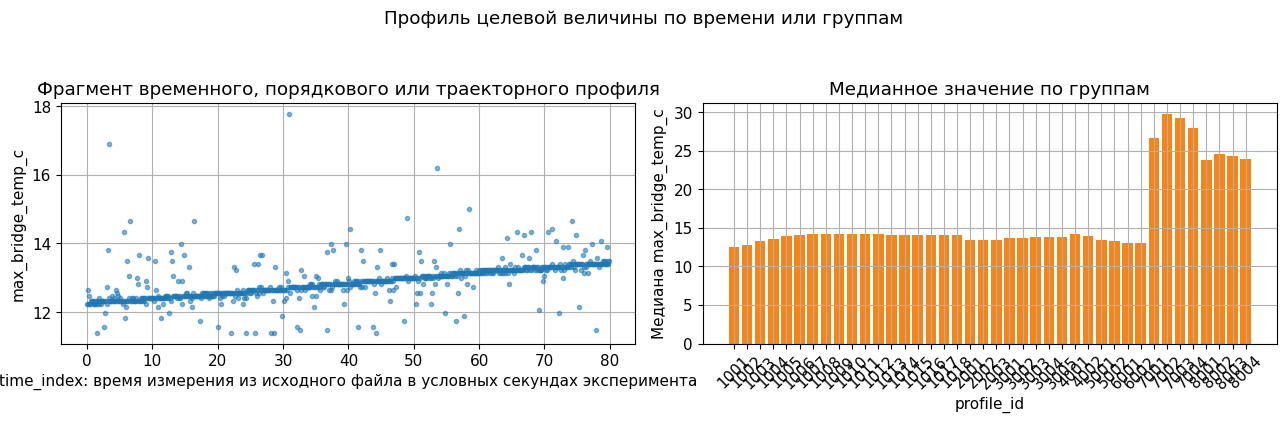

In [14]:
plot_time_or_group_profile(
    full_df,
    'max_bridge_temp_c',
    "Профиль целевой величины по времени или группам",
)


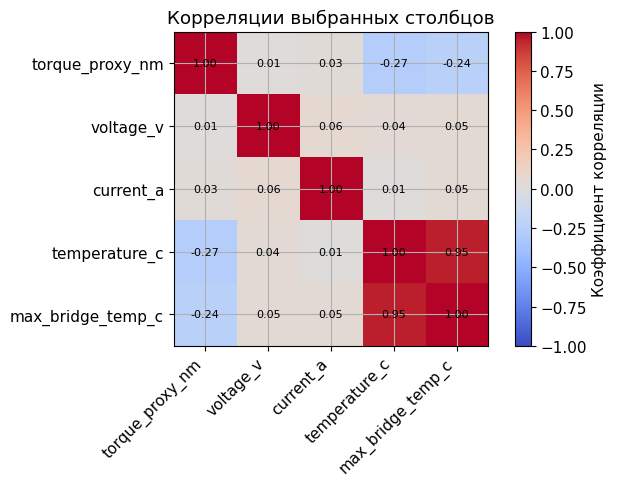

In [15]:
plot_correlation_heatmap(
    full_df,
    [column for column in analysis_columns if column in full_df.columns],
    "Корреляции выбранных столбцов",
)


In [16]:
print_top_correlations(
    full_df,
    analysis_columns,
    'max_bridge_temp_c',
)


Интерпретация: высокая корреляция показывает сильную линейную связь, но не доказывает причинность. Также необходимо проверить, не является ли признак производным от целевой переменной.


,correlation
temperature_c,0.946235
torque_proxy_nm,-0.238434
current_a,0.049276
voltage_v,0.048852


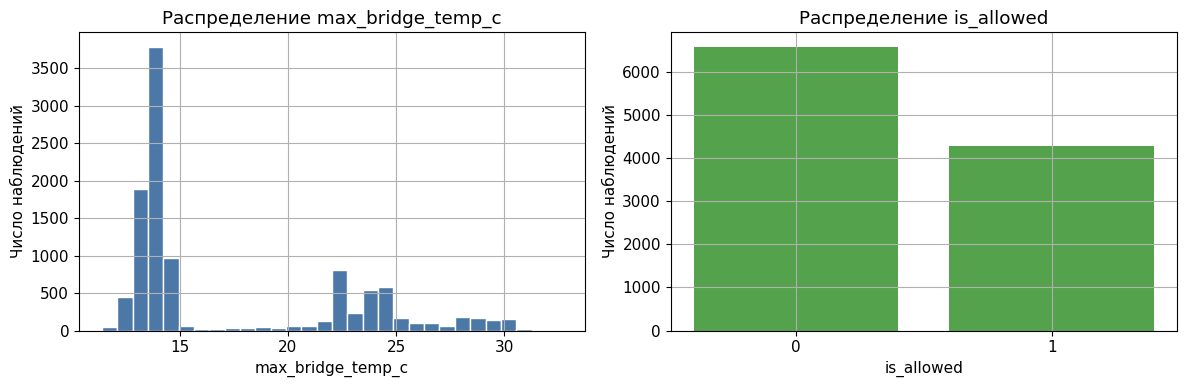

In [17]:
target_columns = ['max_bridge_temp_c', 'is_allowed']
available_targets = existing_columns(full_df, target_columns)
fig, axes = plt.subplots(1, len(available_targets), figsize=(6 * len(available_targets), 4))
axes = np.atleast_1d(axes)
for ax, column in zip(axes, available_targets):
    if full_df[column].nunique(dropna=True) <= 10:
        counts = full_df[column].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, color="#54a24b")
        ax.set_ylabel("Число наблюдений")
    else:
        ax.hist(full_df[column].dropna(), bins=30, color="#4c78a8", edgecolor="white")
        ax.set_ylabel("Число наблюдений")
    ax.set_xlabel(column)
    ax.set_title(f"Распределение {column}")
plt.tight_layout()
plt.show()


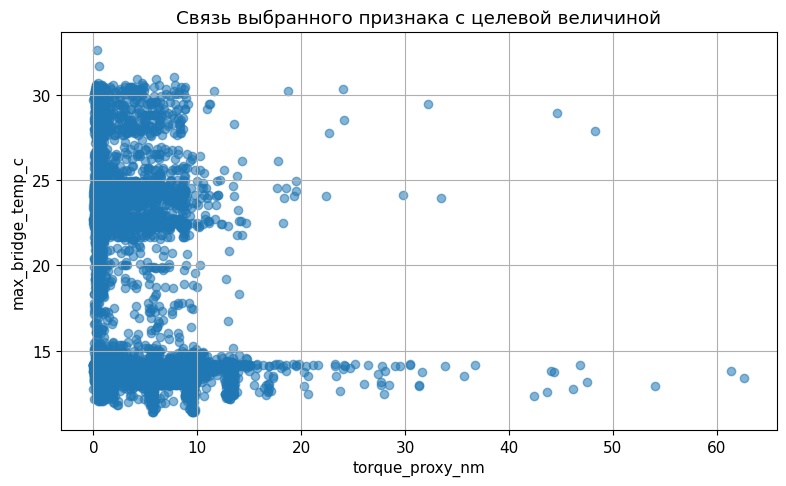

In [18]:
x_column = analysis_columns[0]
y_column = "max_bridge_temp_c"
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(full_df[x_column], full_df[y_column], alpha=0.55)
ax.set_xlabel(x_column)
ax.set_ylabel(y_column)
ax.set_title("Связь выбранного признака с целевой величиной")
plt.tight_layout()
plt.show()


In [19]:
diagnostic_preview_columns = diagnostics_df.columns[: min(10, len(diagnostics_df.columns))].tolist()
diagnostics_df[diagnostic_preview_columns].head()


,sample_id,max_bridge_temp_c,fault_code,fault_label,T1,T2,T3,Ia_original,Ib_original,IDC_original
0,1,12.229922,F0,normal_operation,10.577242,11.483951,12.229922,1.001955,-6.036168,-0.268817
1,2,12.646151,F0,normal_operation,11.732168,11.483951,12.646151,1.050831,-6.036168,-0.171065
2,3,12.229922,F0,normal_operation,10.659462,11.401305,12.229922,1.050831,-5.987292,-0.219941
3,4,12.479497,F0,normal_operation,11.566642,11.483951,12.479497,1.099707,-5.938416,-0.219941
4,5,12.229922,F0,normal_operation,10.577242,11.153638,12.229922,1.001955,-5.938416,-0.317693


## Интерпретация результатов первичного анализа

В отчете необходимо отделить факты от интерпретации. Фактами являются число
наблюдений, число пропусков, диапазоны признаков и вид распределений.
Интерпретация должна объяснять, какие особенности источника могут повлиять на
модель: временная зависимость, неодинаковая длина групп, расчетные признаки,
производные целевые переменные и диагностические столбцы.


## Типовые ошибки интерпретации

1. Считать `sample_id` физическим признаком. Это служебный номер строки.
2. Делать вывод о причинности только по корреляции. Корреляция показывает
   совместное изменение, но не доказывает физический механизм.
3. Автоматически переносить diagnostics-CSV в признаки модели. В нем могут
   находиться производные величины и элементы разметки.
4. Игнорировать групповой или временной порядок наблюдений. Для временных и
   профильных данных это может привести к завышенной оценке качества модели.

## Контрольные вопросы и мини-задания

1. Что является единицей наблюдения в данном источнике?
2. Какие столбцы являются целевыми переменными для занятий 02 и 03?
3. Найдите два признака с наибольшей корреляцией с целевой переменной и
   объясните, почему корреляция не равна причинности.
4. Измените `analysis_columns`, добавив один диагностический столбец, и
   объясните, почему его нельзя автоматически считать допустимым признаком
   модели.


## Задание

1. Опишите источник данных, объект наблюдения и единицу наблюдения.
2. Разделите столбцы на измеряемые, расчетные, служебные и диагностические.
3. Постройте не менее двух графиков и одну таблицу описательной статистики.
4. Объясните, какие столбцы могут привести к утечке данных в занятиях 02-03.
5. Сформулируйте индивидуальный инженерный вывод.
